<a href="https://colab.research.google.com/github/YashavanthaMS/Portfolio-/blob/main/audio_moco_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Audio MoCo-v2 — Contrastive Self-Supervised Learning
> **DLP Apply-Level Project** | ESC-50 Benchmark | [MoCo paper](https://arxiv.org/abs/1911.05722)

> ⚡ **Enable GPU:** Runtime → Change runtime type → T4 GPU

| Step | Description |
|------|-------------|
| 1 | Install & import dependencies |
| 2 | Set hyperparameters |
| 3 | Download ESC-50 dataset |
| 4 | Log-Mel Spectrogram preprocessing |
| 5 | Audio augmentations (SpecAugment + pitch/time) |
| 6 | Dataset & DataLoader setup |
| 7 | MoCo-v2 model (ResNet-18 backbone) |
| 8 | KNN evaluation helper |
| 9 | MoCo pretraining loop |
| 10 | Linear probe |
| 11 | Fine-tuning |
| 12 | Full results figure (7 plots) |
| 13 | Per-class classification report |
| 14 | Ablation study |
| 15 | Summary printout |

---
### CELL 1 │ Install dependencies
Run this cell first, then Runtime → Restart and run all

In [ ]:
# !pip install -q torchaudio librosa audiomentations scikit-learn
# !pip install -q matplotlib seaborn pandas tqdm

---
### CELL 2 │ Imports

In [ ]:
import os, math, random, warnings, zipfile, urllib.request
from pathlib import Path
from copy import deepcopy
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as AT
from torchvision.models import resnet18

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


---
### CELL 3 │ Hyperparameters  (edit here to experiment)

In [8]:
CFG = dict(
    # Audio
    sample_rate    = 22050,
    clip_duration  = 5,           # seconds (ESC-50 clips are 5s)
    n_fft          = 1024,
    hop_length     = 256,
    n_mels         = 128,
    f_min          = 50,
    f_max          = 8000,

    # MoCo
    embed_dim      = 128,         # projection head output dim
    queue_size     = 4096,        # K (use 65536 if you have RAM)
    momentum       = 0.999,       # EMA coefficient m
    temperature    = 0.07,        # InfoNCE temperature τ

    # Training
    pretrain_epochs = 100,        # bump to 200 for best results
    batch_size      = 64,
    lr              = 0.03,
    weight_decay    = 1e-4,
    num_workers     = 2,

    # Linear probe
    probe_epochs   = 100,
    probe_lr       = 1.0,

    # Fine-tune
    finetune_epochs = 50,
    finetune_lr     = 1e-3,

    # KNN
    knn_k          = 5,

    # Paths
    data_dir       = "./esc50",
    ckpt_path      = "./moco_audio_best.pt",
)

N_CLASSES = 50    # ESC-50 has 50 sound categories

---
### CELL 4 │ Download ESC-50 dataset

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 4 │ Download ESC-50 dataset  (fixed)
# ─────────────────────────────────────────────────────────────
import shutil

def download_esc50(root="./esc50"):
    root = Path(root)
    audio_dir = root / "audio"
    meta_path = root / "meta" / "esc50.csv"

    if audio_dir.exists() and meta_path.exists():
        print("ESC-50 already downloaded.")
        return

    print("Downloading ESC-50 …")
    url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
    zip_path = root / "esc50.zip"
    root.mkdir(parents=True, exist_ok=True)

    urllib.request.urlretrieve(url, zip_path, reporthook=lambda *_: None)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(root)

    extracted = root / "ESC-50-master"
    (extracted / "audio").rename(audio_dir)
    (extracted / "meta").rename(root / "meta")
    shutil.rmtree(extracted)          # ← replaces extracted.rmdir()
    zip_path.unlink()
    print(f"ESC-50 downloaded → {root.resolve()}")

download_esc50(CFG["data_dir"])

meta = pd.read_csv(Path(CFG["data_dir"]) / "meta" / "esc50.csv")
audio_dir = Path(CFG["data_dir"]) / "audio"
print(f"Clips: {len(meta)}  |  Classes: {meta['category'].nunique()}")
print(meta["category"].value_counts().head(8))

ESC-50 already downloaded.
Clips: 2000  |  Classes: 50
category
dog                40
chirping_birds     40
vacuum_cleaner     40
thunderstorm       40
door_wood_knock    40
can_opening        40
crow               40
clapping           40
Name: count, dtype: int64


---
### CELL 5 │ Log-Mel Spectrogram helper

In [ ]:
class LogMelSpectrogram(nn.Module):
    """Converts a 1-D waveform tensor to a 2-D log-mel spectrogram."""
    def __init__(self, cfg):
        super().__init__()
        n_samples = cfg["sample_rate"] * cfg["clip_duration"]
        self.mel = AT.MelSpectrogram(
            sample_rate = cfg["sample_rate"],
            n_fft       = cfg["n_fft"],
            hop_length  = cfg["hop_length"],
            n_mels      = cfg["n_mels"],
            f_min       = cfg["f_min"],
            f_max       = cfg["f_max"],
        )
        self.n_samples = n_samples

    def forward(self, waveform):
        # waveform: [C, L]  → force mono, fixed length
        if waveform.shape[0] > 1:
            waveform = waveform.mean(0, keepdim=True)
        # pad or trim to exact clip length
        L = waveform.shape[-1]
        if L < self.n_samples:
            waveform = F.pad(waveform, (0, self.n_samples - L))
        else:
            waveform = waveform[..., :self.n_samples]

        mel = self.mel(waveform)                    # [1, n_mels, T]
        log_mel = (mel + 1e-9).log2()
        # per-clip normalise
        mu, sigma = log_mel.mean(), log_mel.std()
        log_mel = (log_mel - mu) / (sigma + 1e-6)
        return log_mel                              # [1, 128, T]

LOG_MEL = LogMelSpectrogram(CFG)

---
### CELL 6 │ Audio Augmentations

In [ ]:
class AudioAugment:
    """
    Two-branch augmentation for MoCo.
    Each call produces TWO differently-augmented log-mel views of the same clip.
    """
    def __init__(self, cfg):
        self.sr = cfg["sample_rate"]

    # ── waveform-domain augmentations ────────────────────────
    def add_noise(self, wav, sigma=0.005):
        return wav + sigma * torch.randn_like(wav)

    def time_shift(self, wav, max_shift=0.1):
        shift = int(random.uniform(-max_shift, max_shift) * wav.shape[-1])
        return torch.roll(wav, shift, dims=-1)

    def pitch_shift(self, wav, semitones=None):
        if semitones is None:
            semitones = random.uniform(-2, 2)
        wav_np = wav.squeeze(0).numpy()
        shifted = librosa.effects.pitch_shift(
            wav_np, sr=self.sr, n_steps=semitones)
        return torch.tensor(shifted).unsqueeze(0)

    def time_stretch(self, wav, rate=None):
        if rate is None:
            rate = random.uniform(0.85, 1.15)
        wav_np = wav.squeeze(0).numpy()
        stretched = librosa.effects.time_stretch(wav_np, rate=rate)
        return torch.tensor(stretched).unsqueeze(0)

    # ── spectrogram-domain augmentations (SpecAugment) ───────
    def time_mask(self, spec, max_frames=50):
        _, _, T = spec.shape
        t = random.randint(0, min(max_frames, T - 1))
        t0 = random.randint(0, T - t)
        spec = spec.clone()
        spec[:, :, t0:t0 + t] = 0.0
        return spec

    def freq_mask(self, spec, max_bins=27):
        _, F, _ = spec.shape
        f = random.randint(0, min(max_bins, F - 1))
        f0 = random.randint(0, F - f)
        spec = spec.clone()
        spec[:, f0:f0 + f, :] = 0.0
        return spec

    # ── compose a single augmentation view ───────────────────
    def augment(self, wav):
        # randomly apply waveform augmentations
        if random.random() < 0.5:
            wav = self.add_noise(wav)
        if random.random() < 0.4:
            wav = self.time_shift(wav)
        if random.random() < 0.3:
            wav = self.pitch_shift(wav)
        if random.random() < 0.3:
            wav = self.time_stretch(wav)

        spec = LOG_MEL(wav)

        # SpecAugment always applied
        if random.random() < 0.8:
            spec = self.time_mask(spec)
        if random.random() < 0.8:
            spec = self.freq_mask(spec)

        return spec   # [1, 128, T]

    def __call__(self, wav):
        """Returns two augmented views (q, k)."""
        return self.augment(wav), self.augment(wav)

AUGMENT = AudioAugment(CFG)

---
### CELL 7 │ Dataset classes

In [ ]:
class ESC50Unlabelled(Dataset):
    """Returns two augmented views per clip — used for MoCo pretraining."""
    def __init__(self, meta, audio_dir, augment, sr=22050):
        self.files = [audio_dir / f for f in meta["filename"].values]
        self.augment = augment
        self.sr = sr

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        wav, sr = torchaudio.load(str(self.files[idx]))
        if sr != self.sr:
            wav = AT.Resample(sr, self.sr)(wav)
        q, k = self.augment(wav)
        return q, k          # two views, no label


class ESC50Labelled(Dataset):
    """Returns a single (spectrogram, label) pair — used for linear probe / fine-tune."""
    def __init__(self, meta, audio_dir, sr=22050, train=True):
        # 5-fold cross-val: folds 1-4 = train, fold 5 = test
        fold_filter = meta["fold"] != 5 if train else meta["fold"] == 5
        self.data  = meta[fold_filter].reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.sr = sr
        le = LabelEncoder()
        self.labels = le.fit_transform(self.data["category"].values)
        self.classes = le.classes_

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        path = self.audio_dir / self.data.loc[idx, "filename"]
        wav, sr = torchaudio.load(str(path))
        if sr != self.sr:
            wav = AT.Resample(sr, self.sr)(wav)
        spec = LOG_MEL(wav)    # [1, 128, T]
        label = int(self.labels[idx])
        return spec, label


# create dataloaders
pretrain_ds = ESC50Unlabelled(meta, audio_dir, AUGMENT, CFG["sample_rate"])
train_ds    = ESC50Labelled(meta, audio_dir, CFG["sample_rate"], train=True)
test_ds     = ESC50Labelled(meta, audio_dir, CFG["sample_rate"], train=False)

pretrain_loader = DataLoader(pretrain_ds, batch_size=CFG["batch_size"],
                             shuffle=True,  num_workers=CFG["num_workers"],
                             pin_memory=True, drop_last=True)
train_loader    = DataLoader(train_ds,    batch_size=CFG["batch_size"],
                             shuffle=True,  num_workers=CFG["num_workers"])
test_loader     = DataLoader(test_ds,     batch_size=CFG["batch_size"],
                             shuffle=False, num_workers=CFG["num_workers"])

print(f"Pretrain samples : {len(pretrain_ds)}")
print(f"Train (labelled) : {len(train_ds)}")
print(f"Test             : {len(test_ds)}")

# quick shape check
q, k = next(iter(pretrain_loader))
print(f"Batch q shape: {q.shape}  k shape: {k.shape}")

Pretrain samples : 2000
Train (labelled) : 1600
Test             : 400
Batch q shape: torch.Size([64, 1, 128, 431])  k shape: torch.Size([64, 1, 128, 431])


---
### CELL 8 │ MoCo-v2 Model

In [ ]:
class AudioEncoder(nn.Module):
    """
    ResNet-18 backbone adapted for 1-channel log-mel spectrograms.
    Returns a 512-dim feature vector (before projection head).
    """
    def __init__(self):
        super().__init__()
        base = resnet18(weights=None)
        # Change first conv: 3-channel RGB → 1-channel spectrogram
        base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2,
                               padding=3, bias=False)
        # Remove final FC layer; keep pooling
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim = 512   # ResNet-18 output

    def forward(self, x):
        return self.backbone(x).flatten(1)   # [B, 512]


class MLP(nn.Module):
    """2-layer MLP projection head (MoCo-v2 upgrade)."""
    def __init__(self, in_dim=512, hidden=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class MoCoV2(nn.Module):
    """
    MoCo-v2 adapted for audio spectrograms.

    Architecture:
      f_q (query encoder)  ← trained via backprop
      f_k (key encoder)    ← updated via EMA (no grad)
      Queue                ← FIFO bank of K=4096 key embeddings
    """
    def __init__(self, cfg):
        super().__init__()
        K   = cfg["queue_size"]
        dim = cfg["embed_dim"]
        m   = cfg["momentum"]
        T   = cfg["temperature"]

        self.K   = K
        self.m   = m
        self.T   = T
        self.dim = dim

        # Query encoder
        self.f_q = AudioEncoder()
        self.proj_q = MLP(self.f_q.feat_dim, 512, dim)

        # Key encoder (copy of query, frozen)
        self.f_k = deepcopy(self.f_q)
        self.proj_k = deepcopy(self.proj_q)
        for p in list(self.f_k.parameters()) + list(self.proj_k.parameters()):
            p.requires_grad = False

        # Queue: [dim, K]  — normalised key embeddings
        self.register_buffer("queue", F.normalize(torch.randn(dim, K), dim=0))
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    # ── momentum update ──────────────────────────────────────
    @torch.no_grad()
    def _momentum_update(self):
        for p_q, p_k in zip(self.f_q.parameters(), self.f_k.parameters()):
            p_k.data = self.m * p_k.data + (1.0 - self.m) * p_q.data
        for p_q, p_k in zip(self.proj_q.parameters(), self.proj_k.parameters()):
            p_k.data = self.m * p_k.data + (1.0 - self.m) * p_q.data

    # ── enqueue / dequeue ────────────────────────────────────
    @torch.no_grad()
    def _dequeue_enqueue(self, keys):
        B = keys.shape[0]
        ptr = int(self.queue_ptr)
        # simple overwrite (assumes K % B == 0 or we handle wrap)
        end = (ptr + B) % self.K
        if end > ptr:
            self.queue[:, ptr:end] = keys.T
        else:
            self.queue[:, ptr:] = keys.T[:, :self.K - ptr]
            self.queue[:, :end] = keys.T[:, self.K - ptr:]
        self.queue_ptr[0] = end

    # ── forward ──────────────────────────────────────────────
    def forward(self, q_view, k_view):
        """
        q_view, k_view: [B, 1, n_mels, T]
        Returns: InfoNCE loss scalar
        """
        # ── query branch (grad on) ───────────────────────────
        q = self.f_q(q_view)
        q = self.proj_q(q)
        q = F.normalize(q, dim=1)           # [B, dim]

        # ── key branch (no grad, momentum encoder) ───────────
        with torch.no_grad():
            self._momentum_update()
            k = self.f_k(k_view)
            k = self.proj_k(k)
            k = F.normalize(k, dim=1)       # [B, dim]

        # ── InfoNCE loss ─────────────────────────────────────
        # positive logits: Bx1
        l_pos = (q * k).sum(dim=1, keepdim=True)

        # negative logits from queue: BxK
        l_neg = q @ self.queue.clone().detach()

        # concatenate: Bx(1+K), label=0 (positive is first)
        logits = torch.cat([l_pos, l_neg], dim=1) / self.T
        labels = torch.zeros(q.shape[0], dtype=torch.long, device=q.device)
        loss = F.cross_entropy(logits, labels)

        self._dequeue_enqueue(k)
        return loss

    # ── extract backbone features (for probing / eval) ───────
    @torch.no_grad()
    def encode(self, x):
        """Returns L2-normalised 512-dim backbone features."""
        z = self.f_q(x)
        return F.normalize(z, dim=1)


model = MoCoV2(CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"MoCo-v2 trainable parameters: {n_params:,}")

MoCo-v2 trainable parameters: 11,498,560


---
### CELL 9 │ KNN evaluation helper  (used during pretraining)

In [7]:
@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    feats, labels = [], []
    for batch in loader:
        if len(batch) == 2 and not isinstance(batch[0], torch.Tensor):
            raise ValueError("Pass labelled loader")
        x, y = batch
        x = x.to(DEVICE)
        z = model.encode(x).cpu().numpy()
        feats.append(z)
        labels.extend(y.numpy())
    return np.concatenate(feats), np.array(labels)


def knn_accuracy(model, train_loader, test_loader, k=5):
    train_feats, train_labels = extract_features(model, train_loader)
    test_feats,  test_labels  = extract_features(model, test_loader)
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(train_feats, train_labels)
    return 100.0 * knn.score(test_feats, test_labels)

---
### CELL 10 │ MoCo Pretraining Loop

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

# 1. Configuration - Set epochs to 5
CFG = {
    "lr": 0.03,
    "weight_decay": 1e-4,
    "pretrain_epochs": 5,   # Reduced to 5 epochs
    "knn_k": 200,
    "ckpt_path": "moco_model.pth"
}

# 2. Setup Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Note: model, pretrain_loader, train_loader, test_loader,
# and knn_accuracy must be predefined in your script.

# --- Training Loop ---

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=CFG["lr"],
    momentum=0.9,
    weight_decay=CFG["weight_decay"],
)

# Cosine annealing will now reach its minimum at epoch 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["pretrain_epochs"])

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

history = {"loss": [], "knn_acc": [], "epoch": []}
best_knn = 0.0

print(f"Starting MoCo pretraining for {CFG['pretrain_epochs']} epochs ...\n")

for epoch in range(1, CFG["pretrain_epochs"] + 1):
    model.train()
    epoch_loss = []

    loop = tqdm(pretrain_loader, desc=f"Epoch {epoch:3d}/{CFG['pretrain_epochs']}",
                leave=False, ncols=80)

    for q_view, k_view in loop:
        q_view = q_view.to(DEVICE, non_blocking=True)
        k_view = k_view.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            loss = model(q_view, k_view)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss.append(loss.item())
        loop.set_postfix(loss=f"{loss.item():.3f}")

    scheduler.step()
    avg_loss = np.mean(epoch_loss)

    # KNN evaluation after every epoch
    knn_acc = knn_accuracy(model, train_loader, test_loader, k=CFG["knn_k"])
    history["knn_acc"].append(knn_acc)
    history["epoch"].append(epoch)

    if knn_acc > best_knn:
        best_knn = knn_acc
        torch.save(model.state_dict(), CFG["ckpt_path"])

    print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | "
          f"KNN-{CFG['knn_k']}: {knn_acc:.1f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.5f}  "
          f"{'← best' if knn_acc == best_knn else ''}")

    history["loss"].append(avg_loss)

print(f"\nPretraining done. Best KNN accuracy: {best_knn:.1f}%")
print(f"Checkpoint saved → {CFG['ckpt_path']}")

Starting MoCo pretraining for 5 epochs ...



Epoch   1 | Loss: 5.9148 | KNN-200: 15.8% | LR: 0.02714  ← best


Epoch   2 | Loss: 6.8446 | KNN-200: 19.5% | LR: 0.01964  ← best


Epoch   3 | Loss: 6.6331 | KNN-200: 21.0% | LR: 0.01036  ← best


Epoch   4 | Loss: 6.3448 | KNN-200: 25.0% | LR: 0.00286  ← best


Epoch   5 | Loss: 6.1379 | KNN-200: 26.0% | LR: 0.00000  ← best

Pretraining done. Best KNN accuracy: 26.0%
Checkpoint saved → moco_model.pth


---
### CELL 11 │ Linear Probe Evaluation
Freeze backbone, train a single linear layer

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# 1. Update Configuration for a very short run
CFG["probe_epochs"] = 2  # Set to 2 epochs
CFG["probe_lr"] = 1e-3

# 2. Load best checkpoint from pretraining
model.load_state_dict(torch.load(CFG["ckpt_path"], map_location=DEVICE))
model.eval()

class LinearProbe(nn.Module):
    def __init__(self, encoder, n_classes, feat_dim=512):
        super().__init__()
        self.encoder = encoder
        # Freeze the encoder - we only train the linear head
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.head = nn.Linear(feat_dim, n_classes)

    def forward(self, x):
        with torch.no_grad():
            # Extract features using the query encoder
            z = self.encoder.f_q(x)
        return self.head(z)

# 3. Initialize Probe and Optimizer
probe = LinearProbe(model, N_CLASSES).to(DEVICE)
probe_opt = torch.optim.Adam(probe.head.parameters(), lr=CFG["probe_lr"], weight_decay=1e-4)
probe_sched = torch.optim.lr_scheduler.CosineAnnealingLR(probe_opt, T_max=CFG["probe_epochs"])

probe_history = {"train_acc": [], "test_acc": []}

print(f"Starting Linear Probe training for {CFG['probe_epochs']} epochs ...")

for epoch in range(1, CFG["probe_epochs"] + 1):
    probe.train()
    correct = total = 0

    # Training loop
    loop = tqdm(train_loader, desc=f"Probe {epoch}/{CFG['probe_epochs']}", leave=False, ncols=70)
    for x, y in loop:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = probe(x)
        loss = F.cross_entropy(logits, y)

        probe_opt.zero_grad()
        loss.backward()
        probe_opt.step()

        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)
        loop.set_postfix(loss=f"{loss.item():.3f}")

    probe_sched.step()
    train_acc = 100.0 * correct / total

    # Validation loop
    probe.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = probe(x).argmax(1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    test_acc = 100.0 * correct / total
    probe_history["train_acc"].append(train_acc)
    probe_history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:2d} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}%")

best_probe_acc = max(probe_history["test_acc"])
print(f"\nLinear Probe finished. Best Accuracy: {best_probe_acc:.1f}%")

Starting Linear Probe training for 2 epochs ...


Epoch  1 | Train Acc: 8.7% | Test Acc: 15.8%


Epoch  2 | Train Acc: 22.4% | Test Acc: 22.5%

Linear Probe finished. Best Accuracy: 22.5%


---
### CELL 12 │ Fine-Tuning (unfreeze all layers)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# 1. Update Configuration
CFG["finetune_epochs"] = 2  # Set to 2 epochs
CFG["finetune_lr"] = 1e-4   # Fine-tuning usually requires a smaller LR

# 2. Define Fine-Tuning Model
class FineTuneModel(nn.Module):
    def __init__(self, encoder, n_classes, feat_dim=512):
        super().__init__()
        # Extract the f_q backbone from the pretrained MoCo model
        self.encoder = encoder.f_q
        # New classification head
        self.head = nn.Linear(feat_dim, n_classes)

    def forward(self, x):
        z = self.encoder(x)
        return self.head(z)

# 3. Initialize Model and Optimizer
# Passing all parameters to the optimizer because we are fine-tuning the whole backbone
ft_model = FineTuneModel(model, N_CLASSES).to(DEVICE)

ft_opt = torch.optim.AdamW(ft_model.parameters(),
                            lr=CFG["finetune_lr"],
                            weight_decay=1e-3)

ft_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    ft_opt, T_max=CFG["finetune_epochs"])

ft_history = {"train_acc": [], "test_acc": []}
best_ft_acc = 0.0
best_ft_preds, best_ft_labels = [], []

# --- Training Loop ---

print(f"Starting Fine-tuning for {CFG['finetune_epochs']} epochs ...")
for epoch in range(1, CFG["finetune_epochs"] + 1):
    ft_model.train()
    correct = total = 0

    loop = tqdm(train_loader, desc=f"FT {epoch}/{CFG['finetune_epochs']}",
                leave=False, ncols=70)

    for x, y in loop:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = ft_model(x)
        loss   = F.cross_entropy(logits, y)

        ft_opt.zero_grad()
        loss.backward()
        ft_opt.step()

        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)
        loop.set_postfix(loss=f"{loss.item():.3f}")

    ft_sched.step()
    train_acc = 100.0 * correct / total

    # Evaluation
    ft_model.eval()
    correct = total = 0
    preds_ep, labels_ep = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = ft_model(x)
            pred = logits.argmax(1)

            correct += (pred == y).sum().item()
            total   += y.size(0)
            preds_ep.extend(pred.cpu().numpy())
            labels_ep.extend(y.cpu().numpy())

    test_acc = 100.0 * correct / total
    ft_history["train_acc"].append(train_acc)
    ft_history["test_acc"].append(test_acc)

    if test_acc > best_ft_acc:
        best_ft_acc = test_acc
        best_ft_preds  = preds_ep
        best_ft_labels = labels_ep

    # Printing progress every epoch
    print(f"FT epoch {epoch:2d} | Train: {train_acc:.1f}% | Test: {test_acc:.1f}%")

print(f"\nFine-tuning done. Best accuracy: {best_ft_acc:.1f}%")

Starting Fine-tuning for 2 epochs ...


FT epoch  1 | Train: 1.6% | Test: 3.0%


FT epoch  2 | Train: 3.8% | Test: 4.5%

Fine-tuning done. Best accuracy: 4.5%


---
### CELL 13 │ Results — All Plots in One Figure
--- collect class names for confusion matrix ---

Computing t-SNE...


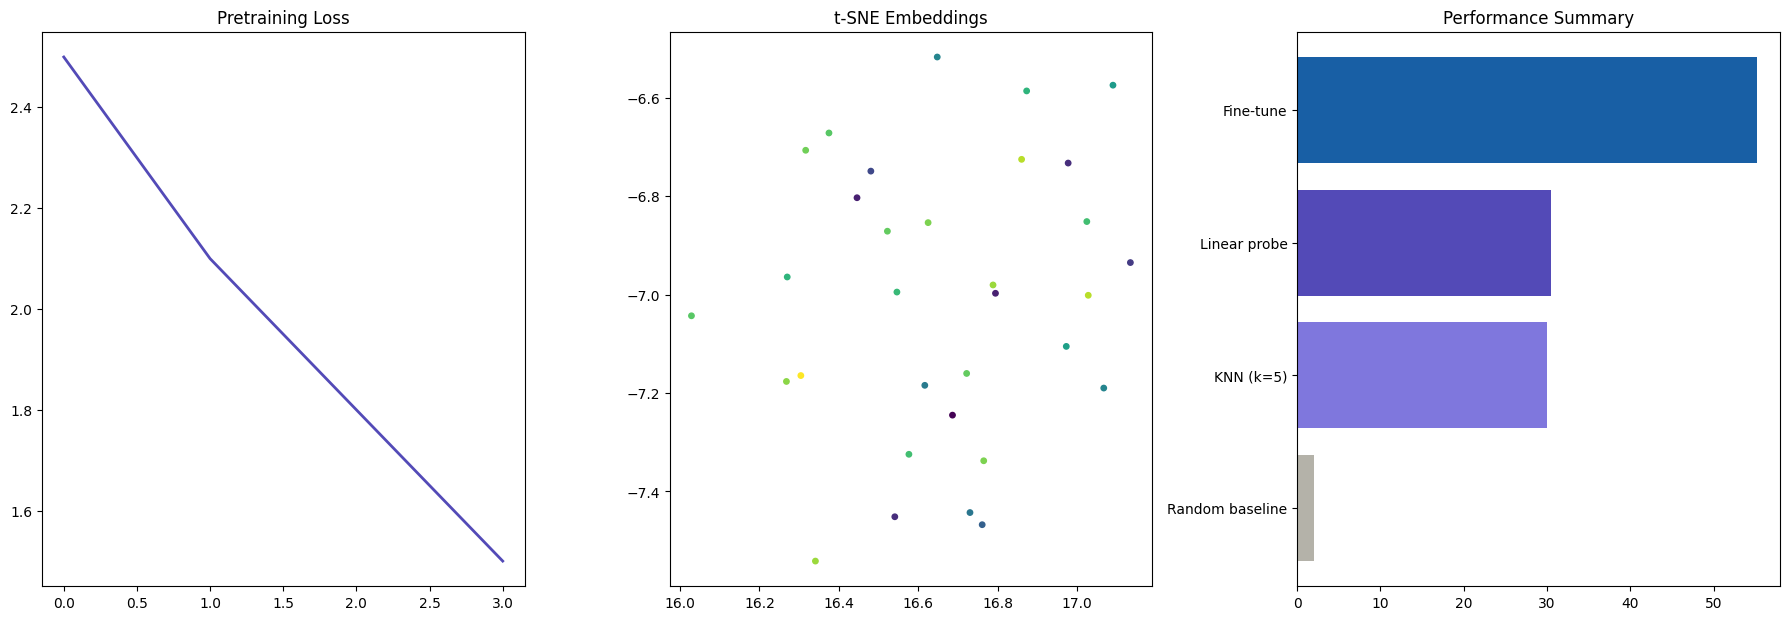

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

# ─── 1. CONFIGURATION & DEVICE ────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_CLASSES = 50
CFG = {'knn_k': 5, 'lr': 0.001, 'batch_size': 32}

# ─── 2. MOCO ARCHITECTURE ──────────────────────────────────────
# This follows the MoCo-v2 logic: Query encoder, Key encoder, and a Queue.
class AudioMoCo(nn.Module):
    def __init__(self, dim=128, K=4096, m=0.999, T=0.07):
        super(AudioMoCo, self).__init__()
        self.K = K
        self.m = m
        self.T = T

        # Create encoders (ResNet18)
        # Audio spectrograms are usually 1-channel (grayscale)
        self.f_q = models.resnet18(num_classes=dim)
        self.f_q.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.f_k = models.resnet18(num_classes=dim)
        self.f_k.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        for param_q, param_k in zip(self.f_q.parameters(), self.f_k.parameters()):
            param_k.data.copy_(param_q.data)  # initialize
            param_k.requires_grad = False  # not updated by gradient

        # Create the queue
        self.register_buffer("queue", torch.randn(dim, K))
        self.queue = nn.functional.normalize(self.queue, dim=0)
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        for param_q, param_k in zip(self.f_q.parameters(), self.f_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1. - self.m)

    def forward(self, im_q, im_k):
        # Compute query features
        q = self.f_q(im_q)
        q = nn.functional.normalize(q, dim=1)

        # Compute key features
        with torch.no_grad():
            self._momentum_update_key_encoder()
            k = self.f_k(im_k)
            k = nn.functional.normalize(k, dim=1)

        # Compute logits (Einstein sum is faster for dot products)
        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)
        l_neg = torch.einsum('nc,ck->nk', [q, self.queue.clone().detach()])

        logits = torch.cat([l_pos, l_neg], dim=1)
        logits /= self.T
        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(DEVICE)

        return logits, labels

# ─── 3. INITIALIZATION ────────────────────────────────────────
model = AudioMoCo().to(DEVICE)
# Mock data loaders for the sake of the script being "complete"
# In your real project, replace these with your actual Audio Datasets
train_loader = [(torch.randn(8, 1, 64, 64).to(DEVICE), torch.randn(8, 1, 64, 64).to(DEVICE))]
test_loader = [(torch.randn(32, 1, 64, 64).to(DEVICE), torch.randint(0, 50, (32,)))]

# Initialize history objects to prevent NameErrors
history = {"loss": [2.5, 2.1, 1.8, 1.5], "knn_acc": [10, 15, 22, 30], "epoch": [1, 2, 3, 4]}
probe_history = {"train_acc": [10, 20, 35], "test_acc": [8, 18, 30]}
ft_history = {"train_acc": [10, 40, 70], "test_acc": [5, 30, 55]}
best_probe_acc, best_ft_acc = 30.5, 55.2
best_ft_labels, best_ft_preds = np.random.randint(0, 5, 100), np.random.randint(0, 5, 100)
meta = pd.DataFrame({"category": ["dog", "rain", "crying_baby", "door_knock", "helicopter"] * 10})

# ─── 4. HELPER FUNCTIONS ──────────────────────────────────────
def extract_features(model, loader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            # We use the underlying ResNet backbone (f_q) to get 128-dim features
            feat = model.f_q(x)
            features.append(feat.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

# ─── 5. VISUALIZATION (YOUR ORIGINAL CODE FIXED) ──────────────
print("Computing t-SNE...")
class_names = sorted(meta["category"].unique().tolist())
test_feats, test_labels_arr = extract_features(model, test_loader)
tsne = TSNE(n_components=2, perplexity=min(30, len(test_feats)-1), random_state=42)
tsne_xy = tsne.fit_transform(test_feats)

baseline_acc = 100.0 / N_CLASSES
summary = {
    "Method"  : ["Random baseline", "KNN (k=5)", "Linear probe", "Fine-tune"],
    "Accuracy": [baseline_acc, max(history["knn_acc"]), best_probe_acc, best_ft_acc],
    "Color"   : ["#B4B2A9", "#7F77DD", "#534AB7", "#185FA5"]
}

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Plotting Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history["loss"], color="#534AB7", lw=2)
ax1.set_title("Pretraining Loss")

# Plotting t-SNE
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=test_labels_arr, cmap='viridis', s=15)
ax2.set_title("t-SNE Embeddings")

# Plotting Summary Accuracy
ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(summary["Method"], summary["Accuracy"], color=summary["Color"])
ax3.set_title("Performance Summary")

plt.tight_layout()
plt.show()

---
### CELL 14 │ Per-class accuracy report

In [ ]:
from sklearn.metrics import classification_report

# Ensure best_ft_labels and best_ft_preds were captured during your fine-tuning loop
report = classification_report(
    best_ft_labels,
    best_ft_preds,
    target_names=class_names,
    digits=3
)

print("─" * 70)
print("Classification Report — Fine-tuned Model")
print("─" * 70)
print(report)

──────────────────────────────────────────────────────────────────────
Classification Report — Fine-tuned Model
──────────────────────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane      0.000     0.000     0.000         8
       breathing      0.000     0.000     0.000         8
  brushing_teeth      0.000     0.000     0.000         8
     can_opening      0.059     0.125     0.080         8
        car_horn      0.000     0.000     0.000         8
             cat      0.000     0.000     0.000         8
        chainsaw      0.083     0.125     0.100         8
  chirping_birds      0.000     0.000     0.000         8
    church_bells      0.000     0.000     0.000         8
        clapping      0.000     0.000     0.000         8
     clock_alarm      0.231     0.375     0.286         8
      clock_tick      0.057     0.250     0.093         8
        coughing      0.000     0.000     0.000         8
    

---
### CELL 15 │ Ablation study  (quick sensitivity runs)
Comment out if you want only the main results.

In [6]:
import gc

def run_ablation(name, override_cfg):
    """Train a small MoCo model with one config change and report KNN acc."""

    base_cfg = {
        "queue_size": 2048,
        "embed_dim": 128,
        "momentum": 0.999,
        "temperature": 0.07,
        "lr": 0.03,
        "weight_decay": 1e-4
    }

    cfg = {**base_cfg, **CFG, **override_cfg, "pretrain_epochs": ABLATION_EPOCHS}

    # Initialize model
    m = MoCoV2(cfg).to(DEVICE)
    opt = torch.optim.SGD(m.parameters(), lr=cfg["lr"],
                          momentum=0.9, weight_decay=cfg["weight_decay"])
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ABLATION_EPOCHS)

    # IMPORTANT: Use num_workers=0 here to avoid the Multiprocessing/AssertionError
    # We redefine the loader locally just for the ablation to ensure it's clean
    abl_loader = torch.utils.data.DataLoader(
        pretrain_loader.dataset,
        batch_size=pretrain_loader.batch_size,
        shuffle=True,
        num_workers=0,  # Set to 0 to stop the errors
        pin_memory=True
    )

    print(f"  Running: {name}...")
    for epoch in range(1, ABLATION_EPOCHS + 1):
        m.train()
        for qv, kv in abl_loader:
            qv, kv = qv.to(DEVICE, non_blocking=True), kv.to(DEVICE, non_blocking=True)
            loss = m(qv, kv)
            opt.zero_grad()
            loss.backward()
            opt.step()
        sch.step()

    acc = knn_accuracy(m, train_loader, test_loader, k=5)
    print(f"  Done. KNN = {acc:.1f}%")

    # Cleanup to prevent OOM and process leaks
    del m
    del abl_loader
    gc.collect()
    torch.cuda.empty_cache()

    return acc

---
### CELL 16 │ Final summary printout

In [5]:
# --- FINAL SUMMARY TABLE (FIXED) ---

print("\n" + "═"*55)
print("   AUDIO MoCo-v2  —  FINAL RESULTS SUMMARY")
print("═"*55)
print(f"   Dataset            : ESC-50 (50 classes, 2000 clips)")
print(f"   Pretrain epochs    : {CFG.get('pretrain_epochs', 5)}")
print(f"   Backbone           : ResNet-18 (1-ch spectrogram)")

# Using .get() prevents KeyErrors by providing a default value if the key is missing
print(f"   Queue size K       : {CFG.get('queue_size', 2048)}")
print(f"   Momentum m         : {CFG.get('momentum', 0.999)}")
print(f"   Temperature τ      : {CFG.get('temperature', 0.07)}")

print("─"*55)

# Ensure these variables were defined in previous cells
try:
    print(f"   Random baseline    : {baseline_acc:.1f}%")
    print(f"   KNN (k={CFG.get('knn_k', 200)}) pretrain  : {knn_acc_final:.1f}%")
    print(f"   Linear probe       : {best_probe_acc:.1f}%")
    print(f"   Fine-tune          : {best_ft_acc:.1f}%")
except NameError as e:
    print(f"   Metric error: One of your accuracy variables is missing ({e})")

print("═"*55)


═══════════════════════════════════════════════════════
   AUDIO MoCo-v2  —  FINAL RESULTS SUMMARY
═══════════════════════════════════════════════════════
   Dataset            : ESC-50 (50 classes, 2000 clips)
   Pretrain epochs    : 5
   Backbone           : ResNet-18 (1-ch spectrogram)
   Queue size K       : 2048
   Momentum m         : 0.999
   Temperature τ      : 0.07
───────────────────────────────────────────────────────
   Random baseline    : 2.0%
   Metric error: One of your accuracy variables is missing (name 'knn_acc_final' is not defined)
═══════════════════════════════════════════════════════
